# Credit Card Fraud Detection — Preprocessing & Feature Engineering - Parte 2

In questo notebook viene affrontato il problema della rilevazione di frodi su transazioni con carta di credito,
utilizzando il *Credit Card Transactions Fraud Detection Dataset*.

Il contesto simulato è quello di una banca o di un emittente di carte di credito che deve monitorare un elevato volume di transazioni in tempo quasi-reale, individuando tempestivamente quelle potenzialmente fraudolente.
Il problema presenta due caratteristiche fondamentali:

- **Forte sbilanciamento delle classi**: le transazioni fraudolente rappresentano una percentuale molto ridotta del totale.
- **Asimmetria dei costi di errore**: una frode non intercettata genera una perdita economica significativa, mentre il blocco errato di una transazione legittima comporta costi operativi e un impatto sull’esperienza del cliente.

Per questo motivo, l’obiettivo non è massimizzare l’accuratezza complessiva, ma costruire un modello che ottimizzi il compromesso tra intercettazione delle frodi e contenimento dei falsi allarmi, in funzione di considerazioni di business.

La seconda parte del notebook è dedicata:
- preprocessing e feature engineering “base”
- Feature engineering avanzata


In [1]:
#import delle librerie necessarie per:

#Elaborazione dati e grafici
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from itertools import product
import kagglehub

#Costruzione degli algoritmi e aggiunta metriche per la valutazione
import joblib #salvataggio modelli
import shap
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, precision_recall_curve, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

pd.options.display.float_format = '{:.4f}'.format #per visualizzare la tabella in maniera più leggibile, altrimenti vedremmo i numeri indicati con notazione scientifica

In [2]:
# Download ultima versione
path = kagglehub.dataset_download("kartik2112/fraud-detection")

print("Path to dataset files:", path)

df_train = pd.read_csv(path+"/fraudTrain.csv")
df_test  = pd.read_csv(path+"/fraudTest.csv")

print("Shape dataset di Train ", df_train.shape)

Using Colab cache for faster access to the 'fraud-detection' dataset.
Path to dataset files: /kaggle/input/fraud-detection
Shape dataset di Train  (1296675, 23)


In [3]:
## Gestione valori mancanti
df = df_train.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [4]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.9700,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.0113,-82.0483,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.2300,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.1590,-118.1865,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.1100,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.1507,-112.1545,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.0000,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.0343,-112.5611,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.9600,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.6750,-78.6325,0


In [6]:
## Controllo duplicati ---> come abbiamo già osservato nella parte 1 non sono presenti
df.duplicated().sum()

np.int64(0)

Recap decisionale per il Feature Engineering

Da trasformare in ulteriori feature e eliminare:

- 2. trans_date_trans_time (varie feature temporali)
- 3. cc_num (solo come chiave)
- 4. merchant (risk_score_smoothed e txn_count_so_far)
- 6. amt (trasformazione log)
- 11. city (risk_score_smoothed e txn_count_so_far)
- 13. zip (risk_score_smoothed e txn_count_so_far)
- 14. lat (distanza cliente-merchant)
- 15. long (distanza cliente-merchant)
- 16. city_pop (trasformazione log)
- 17. job (risk_score_smoothed e txn_count_so_far)
- 18. dob (calcolo età cliente)
- 21. merch_lat (distanza cliente-merchant)
- 22. merch_long (distanza cliente-merchant)

OHE:

- 5. category
- 9. gender
- 12. state

Da eliminare, id o informazione ridondante:

- 1. Unnamed: 0
- 20. unix_time

Da eliminare, troppo identificative:

- 7. first
- 8. last
- 10. street
- 19. trans_num


In [7]:
## Feature numeriche di base
def add_base_num_features(df):
  df["log_amt"] = np.log1p(df["amt"].clip(lower=0)) #clip a 0 per evitare problemi con eventuali valori anomali futuri
  df["log_city_pop"] = np.log1p(df["city_pop"].clip(lower=0))
  return df

In [8]:
## Feature Temporali
temporal_static = ["hour", "dayofweek", "month"]
temporal_cyclic = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"]

def add_temporal_features(df):
  df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])

  df = df.sort_values("trans_date_trans_time").reset_index(drop=True) #importante anche per le trasformazioni future

  df["hour"] = df["trans_date_trans_time"].dt.hour
  df["dayofweek"] = df["trans_date_trans_time"].dt.dayofweek
  df["is_weekend"] = df["dayofweek"].isin([5,6]).astype(int)
  df["month"] = df["trans_date_trans_time"].dt.month
  df["is_night"] = ((df["hour"] >= 21) | (df["hour"] <= 4)).astype(int)

  #Introduciamo Feature cicliche da utilizzare in via sperimentale
  # --- Ciclicità ora ---
  df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
  df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

  # --- Ciclicità giorno della settimana ---
  df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
  df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

  # --- Ciclicità mese ---
  df["month_sin"] = np.sin(2 * np.pi * (df["month"] - 1) / 12)
  df["month_cos"] = np.cos(2 * np.pi * (df["month"] - 1) / 12)
  return df

Sebbene il dataset copra un periodo di più anni, non è stata introdotta una variabile esplicita “anno”. Questa scelta è motivata dalla volontà di progettare una pipeline scalabile nel tempo, in cui l’aggiunta di nuovi anni di dati non richieda modifiche strutturali al feature space. Le variazioni temporali vengono catturate tramite feature cicliche (ora, giorno della settimana, mese) e tramite feature storiche incrementali, che riflettono in modo naturale il drift dei comportamenti nel tempo.

Le feature temporali sono state rappresentate sia nella loro forma discreta sia tramite una codifica ciclica basata su funzioni seno e coseno. Questo consente di valutare empiricamente l’impatto delle diverse rappresentazioni sui modelli utilizzati, in particolare confrontando modelli lineari e non lineari, senza assumere a priori una scelta ottimale.

In [9]:
## Distanza cliente–merchant (Haversine)

def haversine(df):
  R = 6371

  lat1 = df["lat"]
  lon1 = df["long"]
  lat2 = df["merch_lat"]
  lon2 = df["merch_long"]

  lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
  dlat = lat2 - lat1
  dlon = lon2 - lon1
  a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
  df["cust_merch_km"] = 2 * R * np.arcsin(np.sqrt(a))

  return df

In [10]:
## Feature storiche cliente (cc_num)

def add_customer_history(df, alpha=50, prior=None, stats=None):

  if prior is None:
      prior = df["is_fraud"].mean()

  if stats is None:
      stats = {}

  txn, fraud, rate, delta = [], [], [], []

  for r in df.itertuples(index=False):
      cc = r.cc_num
      y = r.is_fraud
      t = r.trans_date_trans_time

      n_txn, n_fraud, last_t = stats.get(cc, (0, 0, None))

      txn.append(n_txn)
      fraud.append(n_fraud)
      rate.append((n_fraud + alpha*prior)/(n_txn + alpha))
      delta.append(-1 if last_t is None else (t-last_t).total_seconds())

      stats[cc] = (n_txn+1, n_fraud+int(y), t)

  df["cust_txn_count_so_far"] = txn
  df["cust_fraud_count_so_far"] = fraud
  df["cust_fraud_rate_so_far_smoothed"] = rate
  df["cust_delta_prev_sec"] = delta

  return df, stats

In [11]:
## Risk score smoothed (merchant / job / zip / city)
r_cols = ["merchant", "job", "zip", "city"]

def add_risk_score(df, cols, alpha=300, prior=None, stats_map=None):

  """
  Risk score smoothed incrementale (leakage-safe).
  Se prior non è fornito, usa il fraud rate globale del df passato.
  """

  if prior is None:
      prior = df["is_fraud"].mean()

  if stats_map is None:
      stats_map = {c: {} for c in cols}

  for col in cols:
    stats = stats_map[col]

    score, count = [], []

    for r in df.itertuples(index=False):
        key = getattr(r, col)
        y = r.is_fraud


        n_txn, n_fraud = stats.get(key, (0, 0))

        score.append((n_fraud + alpha*prior)/(n_txn + alpha))
        count.append(n_txn)

        stats[key] = (n_txn+1, n_fraud+int(y))

    df[f"{col}_risk_score_smoothed"] = score
    df[f"{col}_txn_count_so_far"] = count
    stats_map[col] = stats

  return df, stats_map

I tassi di frode storici sono stati stimati utilizzando una forma di smoothing bayesiano, che combina lo storico osservato con il tasso di frode globale. Questo approccio consente di ottenere stime robuste anche in presenza di pochi dati storici e di evitare valori estremi non generalizzabili.

$$
\text{rate} =
\frac{n_{\text{fraud}} + \alpha \cdot p_{\text{global}}}
     {n_{\text{txn}} + \alpha}
$$

Il parametro di smoothing **alpha** controlla il peso relativo assegnato al **prior** globale rispetto allo storico osservato ed è stato scelto in funzione della stabilità statistica e della cardinalità della variabile considerata.

Per le feature storiche a livello cliente (**cc_num**) è stato utilizzato un valore di **alpha = 50**. Questa scelta riflette il fatto che lo storico delle transazioni di un singolo cliente tende ad accumularsi rapidamente nel tempo, rendendo affidabili le stime anche con un numero moderato di osservazioni. Un valore di alpha relativamente contenuto consente quindi allo storico del cliente di influenzare il tasso stimato già dopo poche decine di transazioni, pur mantenendo una regolarizzazione sufficiente nelle fasi iniziali.

Per le feature di rischio associate a variabili ad alta cardinalità e maggiore rumorosità, come **merchant, job, city e zip**, è stato invece adottato un valore più elevato (**alpha = 300**). In questi casi, molte modalità presentano un numero ridotto di osservazioni e tassi di frode estremi che non sono statisticamente stabili. Un valore di alpha più alto consente di attenuare l’influenza di campioni piccoli, ancorando le stime al tasso di frode globale finché non viene accumulata evidenza sufficiente, e migliorando così la robustezza e la capacità di generalizzazione delle feature.

Per garantire il massimo rigore metodologico ed evitare anche forme sottili di **leakage concettuale**, il tasso di frode globale utilizzato come **prior** per lo smoothing delle feature storiche è stato stimato esclusivamente sul sottoinsieme di training precedente alla validazione temporale. Tale **prior** viene successivamente mantenuto fisso e utilizzato per la costruzione delle feature storiche sia sul training sia sul validation set.

Questa scelta riflette uno scenario operativo realistico, in cui il tasso di frode globale viene stimato su una finestra storica disponibile e utilizzato come riferimento stabile per la valutazione di nuove transazioni, evitando che informazioni aggregate future influenzino la costruzione delle feature.

**Nota sul calcolo delle feature storiche in validazione**

Il prior globale utilizzato nello smoothing è stimato esclusivamente sul training set.
Per il validation set, le feature storiche (conteggi e risk score smoothed) vengono aggiornate in modo incrementale lungo la sequenza temporale del validation stesso, utilizzando solo informazioni disponibili prima di ciascuna transazione.
Questa scelta simula uno scenario operativo in cui il sistema di scoring mantiene e aggiorna lo stato online durante l’arrivo delle transazioni, producendo probabilità coerenti con un contesto “near real-time”.
Per il test set, invece, lo stato viene inizializzato con l’ultimo stato disponibile dal validation, replicando l’uso in produzione a partire dallo storico più recente.

In alternativa, una validazione più conservativa potrebbe “freezare” lo stato al termine del training; tale variante è lasciata come possibile estensione.

In [14]:
#Nuovo Merchant per cliente

def add_new_merchant_feature(df, seen=None):
    """
    is_new_merchant_for_customer = 1 se il cliente non ha mai transato
    con quel merchant prima di questa transazione
    """
    if seen is None:
      seen = {}  # cc_num -> set di merchant già visti

    is_new = []

    for r in df.itertuples(index=False):
        cc = r.cc_num
        merch = r.merchant

        if cc not in seen:
            seen[cc] = set()

        # nuovo merchant?
        flag = int(merch not in seen[cc])
        is_new.append(flag)

        # aggiorna storico
        seen[cc].add(merch)

    df["new_merchant_for_customer"] = is_new

    return df, seen

In [15]:
## Age da dob (leakage-safe)

def add_age_feature(df):
    df["dob"] = pd.to_datetime(df["dob"], errors="coerce") #così da trasformare in NaT eventuali valori anomali

    # trans_date_trans_time è già essere datetime

    age_years = (df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25
    df["age"] = age_years

    # pulizia valori impossibili / missing
    df.loc[(df["age"] < 0) | (df["age"] > 120), "age"] = np.nan

    if df["age"].isnull().sum() > 0:
        print(f"Warning: {df['age'].isnull().sum()} age values are missing")

    return df

In [16]:
## One-Hot Encoding

ohe_cols = ["category", "state", "gender"]

def get_encoder(df, ohe_cols): #solo su train
  encoder = OneHotEncoder(handle_unknown="ignore",drop="if_binary", sparse_output=False)
  encoder = encoder.fit(df[ohe_cols])
  return encoder

def one_hot_encoding(df, ohe_cols, encoder): #train, validation e test
  ohe = encoder.transform(df[ohe_cols])

  ohe_df = pd.DataFrame(
    ohe,
    columns=encoder.get_feature_names_out(ohe_cols),
    index=df.index
    )

  df_f = pd.concat([df.drop(columns=ohe_cols), ohe_df], axis=1)

  return df_f #così da poter essere usato anche per validation e test

In [17]:
def temporal_train_val_split(df, date_col="trans_date_trans_time", val_months=3):
    df = df.sort_values(date_col).reset_index(drop=True)
    cutoff = df[date_col].max() - pd.DateOffset(months=val_months) #data di cutoff ultima data - mesi indicati
    df_train = df[df[date_col] < cutoff].copy()
    df_val   = df[df[date_col] >= cutoff].copy()

    return df_train, df_val, cutoff

Ulteriori feature e codifica delle categoriche
Vengono introdotte feature addizionali interpretabili: (i) new_merchant_for_customer, che cattura la novelty del merchant rispetto allo storico del cliente, e (ii) age, derivata da dob in modo leakage-safe.
Le variabili categoriche a bassa cardinalità (category, state, gender) vengono codificate tramite One-Hot Encoding. L’encoder viene fittato esclusivamente sul training set e riutilizzato su validation e test con handle_unknown="ignore", evitando che informazioni future influenzino il preprocessing.
Infine, lo split train/validation è temporale (ultimi val_months mesi), coerente con lo scenario di scoring su dati futuri.

###Primo test end-to-end della pipeline
In questa sezione viene eseguito un primo passaggio completo di preprocessing e feature engineering sul training set (senza split train/validation) con l’obiettivo di verificare: (i) corretto ordinamento temporale, (ii) generazione delle feature derivate e storiche, (iii) assenza di colonne non trasformate/di tipo object, e (iv) coerenza dei tipi finali prima della fase di modellazione.
Lo split temporale e la gestione dello stato (stats) tra train/validation/test verranno introdotti nella sezione successiva.

In [18]:
## Primo esperimento di pipeline (non ancora separati train e validation)

df = df_train.copy() #copia dataset da utilizzare

print(f"Ci sono {df.duplicated().sum()} righe duplicate")
df =df.drop_duplicates() #drop righe duplicate

# cast preventivo delle colonne ad alta cardinalità
for col in ["merchant", "job", "zip", "city"]:
  df[col] = df[col].astype(str)

df =add_temporal_features(df) # procede anche all'ordinamento per data
print(f"Dataset - Inizio: {df['trans_date_trans_time'].min()} - Fine: {df['trans_date_trans_time'].max()}")

df = add_base_num_features(df)
df = haversine(df)
df = add_age_feature(df)

df, _ = add_customer_history(df)
df, _ = add_risk_score(df, r_cols)
df, _ = add_new_merchant_feature(df)

encoder = get_encoder(df, ohe_cols) #creazione encoder per ohe

df = one_hot_encoding(df, ohe_cols, encoder)


print("Elaborazioni completate")

Ci sono 0 righe duplicate
Dataset - Inizio: 2019-01-01 00:00:18 - Fine: 2020-06-21 12:13:37
Elaborazioni completate


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Columns: 114 entries, Unnamed: 0 to gender_M
dtypes: datetime64[ns](2), float64(87), int32(3), int64(14), object(8)
memory usage: 1.1+ GB


In [20]:
for i, c in enumerate(df.columns): #verifica delle feature generate
  print(i ," ", c)

0   Unnamed: 0
1   trans_date_trans_time
2   cc_num
3   merchant
4   amt
5   first
6   last
7   street
8   city
9   zip
10   lat
11   long
12   city_pop
13   job
14   dob
15   trans_num
16   unix_time
17   merch_lat
18   merch_long
19   is_fraud
20   hour
21   dayofweek
22   is_weekend
23   month
24   is_night
25   hour_sin
26   hour_cos
27   dow_sin
28   dow_cos
29   month_sin
30   month_cos
31   log_amt
32   log_city_pop
33   cust_merch_km
34   age
35   cust_txn_count_so_far
36   cust_fraud_count_so_far
37   cust_fraud_rate_so_far_smoothed
38   cust_delta_prev_sec
39   merchant_risk_score_smoothed
40   merchant_txn_count_so_far
41   job_risk_score_smoothed
42   job_txn_count_so_far
43   zip_risk_score_smoothed
44   zip_txn_count_so_far
45   city_risk_score_smoothed
46   city_txn_count_so_far
47   new_merchant_for_customer
48   category_entertainment
49   category_food_dining
50   category_gas_transport
51   category_grocery_net
52   category_grocery_pos
53   category_health_fitness
5

In [21]:
print(df.dtypes.value_counts()) #controllo tipi

float64           87
int64             14
object             8
int32              3
datetime64[ns]     2
Name: count, dtype: int64


In [22]:
cat_f = df.select_dtypes(include=['object'])
cat_f.columns

Index(['merchant', 'first', 'last', 'street', 'city', 'zip', 'job',
       'trans_num'],
      dtype='object')

In [23]:
# Effettuiamo comunque un controllo su tutte le feature numeriche per ottenere maggiori info
numeric_df = df.select_dtypes(include=['int64', 'float64', 'int32'])
corr_with_target = numeric_df.corr()['is_fraud'].sort_values(ascending=False)

In [25]:
count =0
for index, row in corr_with_target.items():
  print(f"{count:<4} {index:<32}  {row}")
  count+=1

0    is_fraud                          1.0
1    amt                               0.21940388895887142
2    cust_fraud_rate_so_far_smoothed   0.12993028319632904
3    log_amt                           0.12043919987827932
4    is_night                          0.089403921806906
5    hour_cos                          0.07934291938536997
6    zip_risk_score_smoothed           0.07084834201878906
7    city_risk_score_smoothed          0.06684681266596988
8    merchant_risk_score_smoothed      0.059367957121224536
9    job_risk_score_smoothed           0.051171519789864936
10   category_shopping_net             0.04426062146771136
11   category_grocery_pos              0.03555809689469624
12   state_DE                          0.03452692010847162
13   category_misc_net                 0.025885886801287582
14   new_merchant_for_customer         0.024154340815154194
15   cust_fraud_count_so_far           0.014119496892988054
16   hour                              0.013799370523446722
17   age 

Sebbene le variabili originali amt e city_pop mostrino una correlazione lineare più elevata con la variabile target rispetto alle loro controparti log-trasformate, tale evidenza è in gran parte dovuta alla forte asimmetria delle distribuzioni originali e alla presenza di valori estremi.

La trasformazione logaritmica è stata mantenuta in quanto consente di ridurre l’influenza degli outlier, migliorare la stabilità numerica dei modelli lineari e favorire una migliore generalizzazione; le corrispondenti feature continue verranno pertanto rimosse dalla fase di modellazione.

In [26]:
df_final = df.copy() #checkpoint

In [27]:
def drop_features(df):
  drop_cols = [
    "Unnamed: 0",
    "trans_date_trans_time",
    "cc_num", "dob",
    "first", "last", "street",
    "merchant", "job", "city", "zip",
    "trans_num", "unix_time",
    "lat", "long", "merch_lat", "merch_long",
    "amt", "city_pop"]

  df = df.drop(columns=drop_cols)

  return df

In [28]:
df_final = drop_features(df_final)

In [29]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 95 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   is_fraud                         1296675 non-null  int64  
 1   hour                             1296675 non-null  int32  
 2   dayofweek                        1296675 non-null  int32  
 3   is_weekend                       1296675 non-null  int64  
 4   month                            1296675 non-null  int32  
 5   is_night                         1296675 non-null  int64  
 6   hour_sin                         1296675 non-null  float64
 7   hour_cos                         1296675 non-null  float64
 8   dow_sin                          1296675 non-null  float64
 9   dow_cos                          1296675 non-null  float64
 10  month_sin                        1296675 non-null  float64
 11  month_cos                        1296675 non-null 

In [30]:
#Controllo outlier

outlier_cols = ["cust_txn_count_so_far",
        "cust_fraud_count_so_far",
        "merchant_txn_count_so_far",
        "job_txn_count_so_far",
        "zip_txn_count_so_far",
        "city_txn_count_so_far","log_amt","log_city_pop","cust_merch_km","age",
        "cust_delta_prev_sec","cust_fraud_rate_so_far_smoothed",
        "merchant_risk_score_smoothed","job_risk_score_smoothed",
        "zip_risk_score_smoothed","city_risk_score_smoothed",
        "hour_sin","hour_cos","dow_sin","dow_cos",
        "month_sin","month_cos"]

In [31]:
df_final[outlier_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
cust_txn_count_so_far,1296675.0000,908.8627,677.8042,0.0000,356.0000,777.0000,1342.0000,3122.0000
cust_fraud_count_so_far,1296675.0000,3.8993,5.2444,0.0000,0.0000,0.0000,9.0000,19.0000
merchant_txn_count_so_far,1296675.0000,1023.3852,665.7337,0.0000,467.0000,948.0000,1514.0000,4402.0000
job_txn_count_so_far,1296675.0000,1968.7451,1628.4095,0.0000,704.0000,1547.0000,2828.0000,9778.0000
zip_txn_count_so_far,1296675.0000,924.9422,693.8863,0.0000,360.0000,787.0000,1362.0000,3645.0000
city_txn_count_so_far,1296675.0000,1031.3729,830.5088,0.0000,387.0000,848.0000,1467.0000,5616.0000
log_amt,1296675.0000,3.5335,1.2894,0.6931,2.3656,3.8820,4.4325,10.2733
log_city_pop,1296675.0000,8.3617,2.4516,3.1781,6.6120,7.8067,9.9198,14.8825
cust_merch_km,1296675.0000,76.1147,29.1169,0.0223,55.3349,78.2318,98.5033,152.1172
age,1296675.0000,45.9964,17.3940,13.9220,32.5996,43.9699,57.0705,95.6386


In [32]:
quantile_df = df_final[outlier_cols].quantile([0.25, 0.5, 0.75, 0.95, 0.99, 0.999]).T
max_series = df_final[outlier_cols].describe().T['max']
min_series = df_final[outlier_cols].describe().T['min']

combined_df = pd.concat([min_series, quantile_df, max_series], axis=1)
combined_df

,min,0.2500,0.5000,0.7500,0.9500,0.9900,0.9990,max
cust_txn_count_so_far,0.0000,356.0000,777.0000,1342.0000,2245.0000,2806.0000,3045.0000,3122.0000
cust_fraud_count_so_far,0.0000,0.0000,0.0000,9.0000,14.0000,16.0000,18.0000,19.0000
merchant_txn_count_so_far,0.0000,467.0000,948.0000,1514.0000,2208.0000,2521.0000,3478.0000,4402.0000
job_txn_count_so_far,0.0000,704.0000,1547.0000,2828.0000,5227.0000,7082.0000,8840.0000,9778.0000
zip_txn_count_so_far,0.0000,360.0000,787.0000,1362.0000,2301.0000,2868.0000,3271.0000,3645.0000
city_txn_count_so_far,0.0000,387.0000,848.0000,1467.0000,2625.0000,3758.0000,4937.3260,5616.0000
log_amt,0.6931,2.3656,3.8820,4.4325,5.2848,6.3044,7.3134,10.2733
log_city_pop,3.1781,6.6120,7.8067,9.9198,13.1725,14.2713,14.8825,14.8825
cust_merch_km,0.0223,55.3349,78.2318,98.5033,120.4954,132.0528,140.0045,152.1172
age,13.9220,32.5996,43.9699,57.0705,79.6304,91.3238,93.7248,95.6386


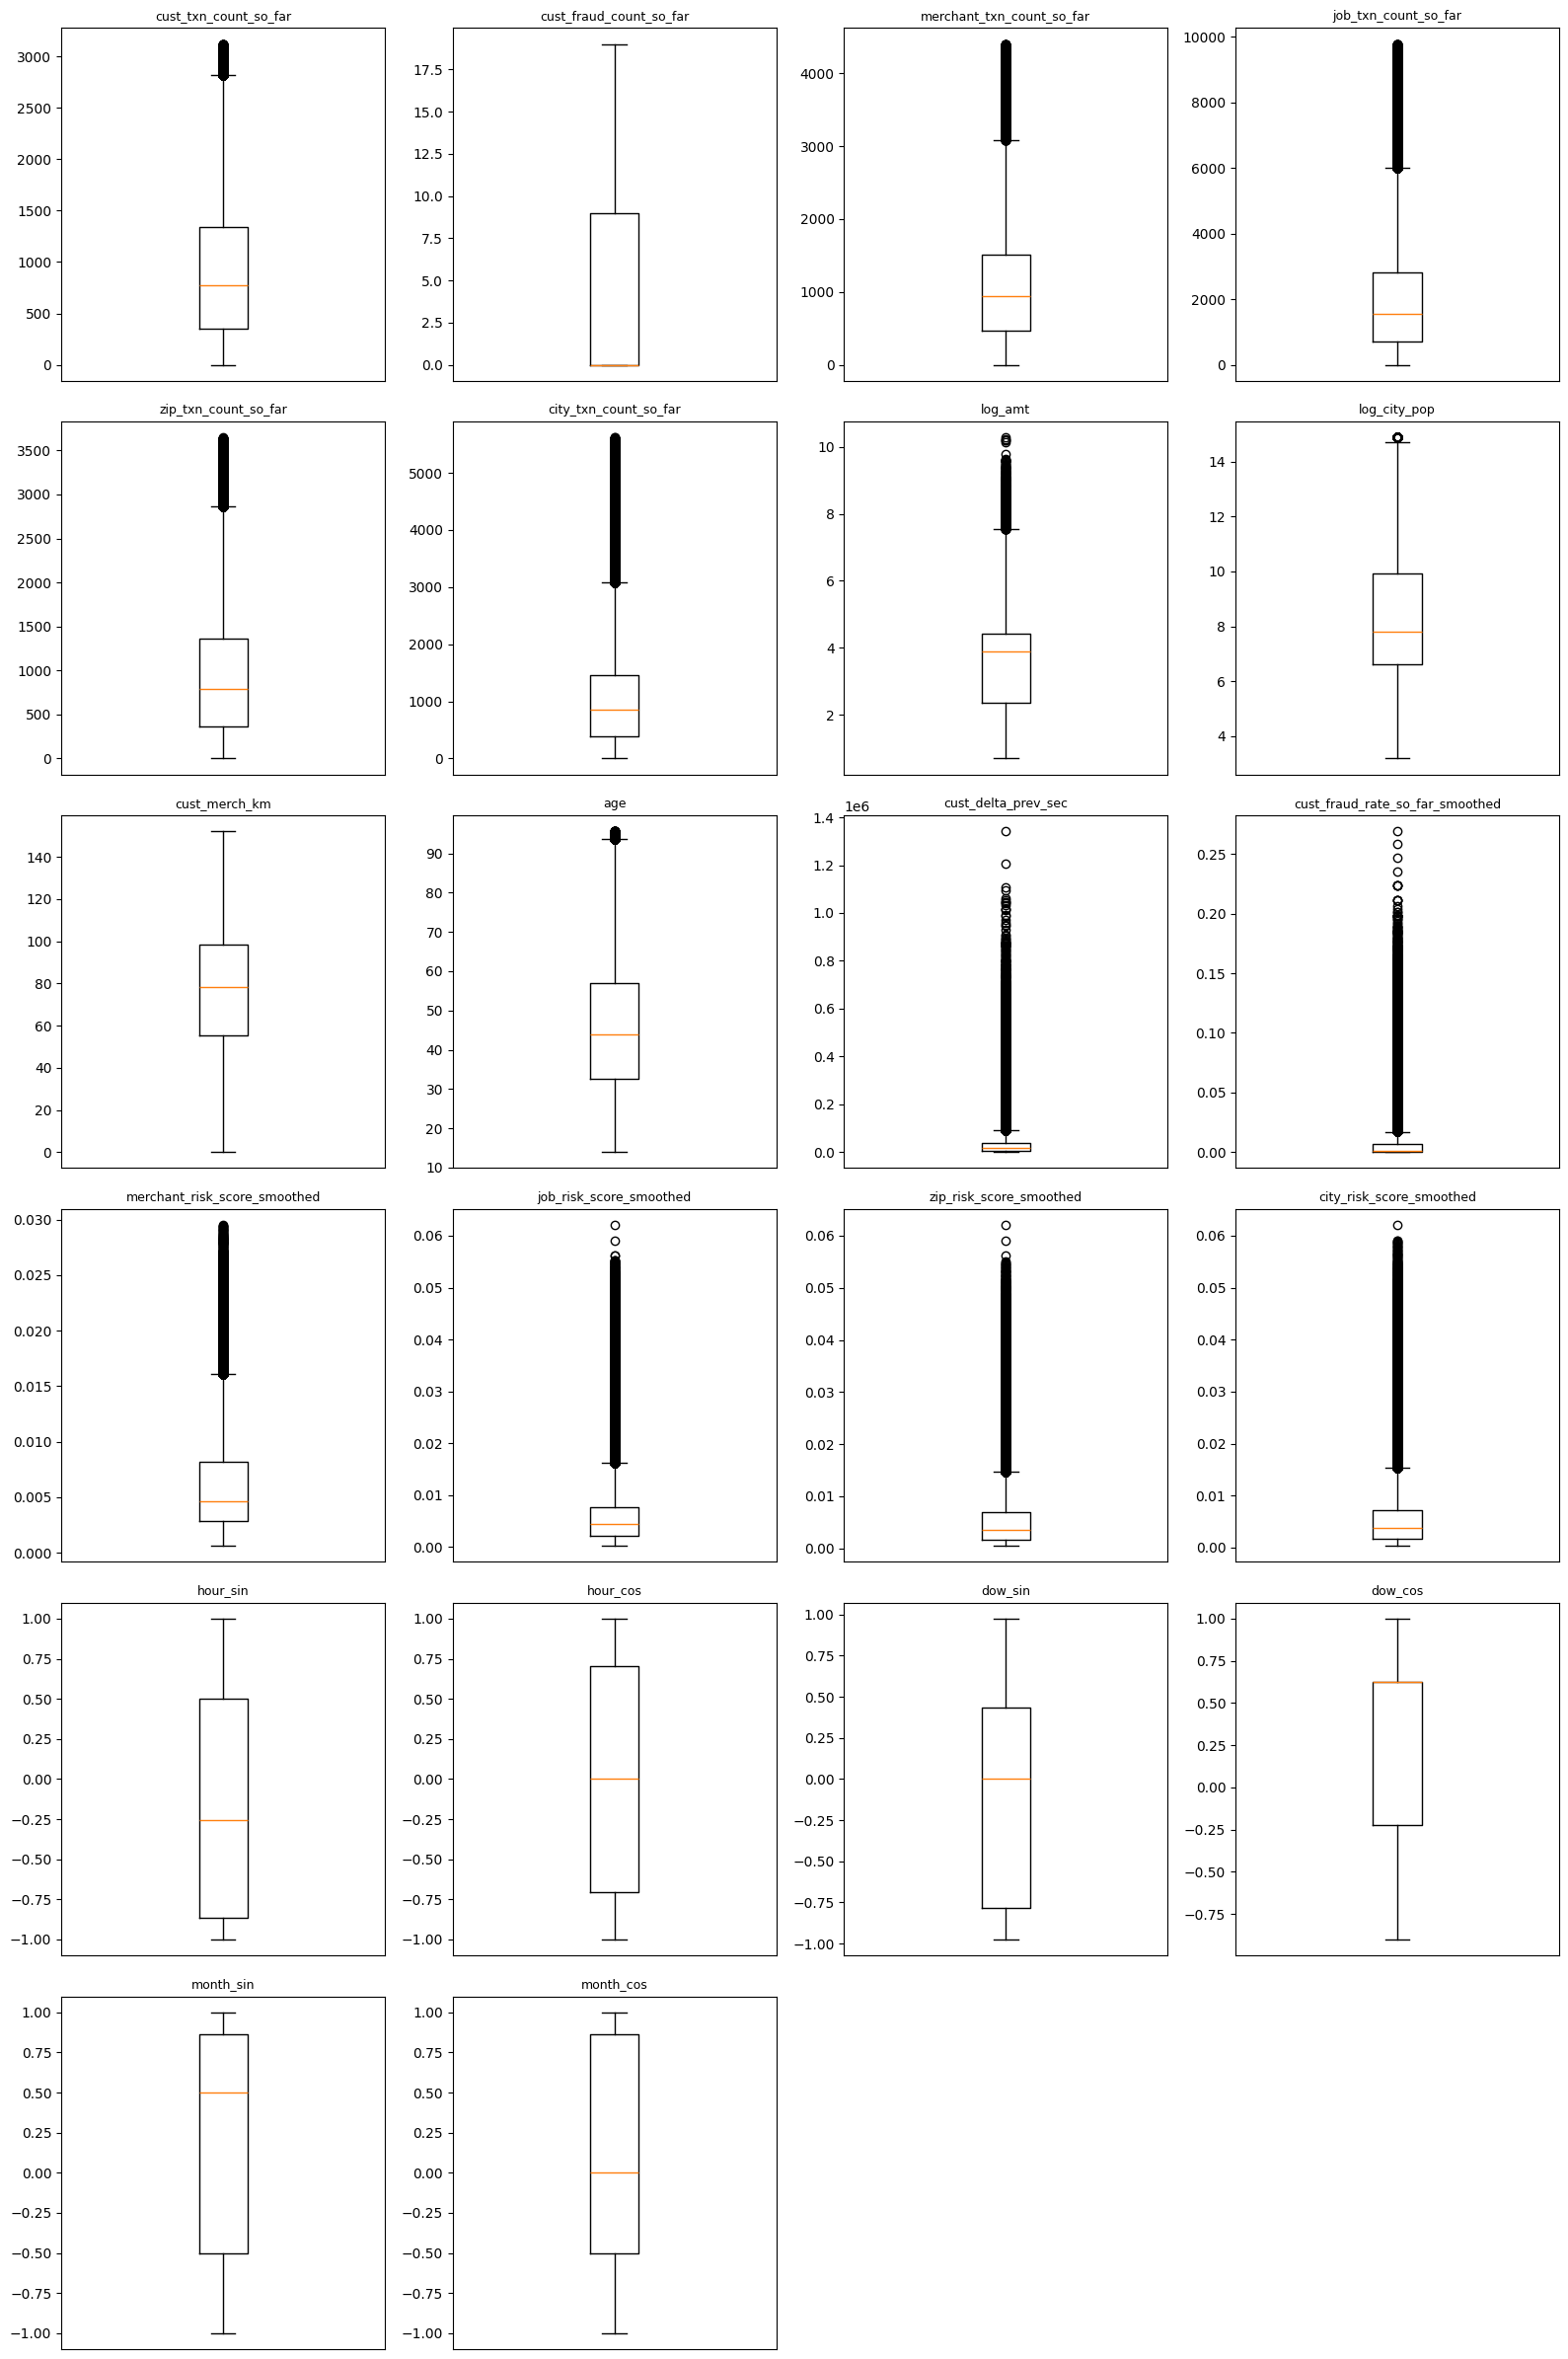

In [33]:
#Di seguito una visualizzazione tramite boxplot:

n_cols = 4                      # numero di plot per riga
n_rows = int(np.ceil(len(outlier_cols) / n_cols))  # numero righe necessario

plt.figure(figsize=(4 * n_cols, 4 * n_rows))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(df_final[col])
    plt.title(col, fontsize=9)
    plt.xticks([])   # tolgo l'etichetta dell'asse x

plt.tight_layout()
plt.show()

In [35]:
df_final["cust_delta_prev_sec"] = df_final["cust_delta_prev_sec"].clip(
    upper=df_final["cust_delta_prev_sec"].quantile(0.999)
)

L’analisi dei boxplot e delle distribuzioni ha evidenziato la presenza di code lunghe in diverse feature storiche e di rischio. Tuttavia, nella maggior parte dei casi tali valori estremi rappresentano comportamenti reali e informativi (es. clienti o merchant con lunga storia transazionale) e non artefatti statistici.

L’unica variabile per cui è stato applicato un clipping esplicito è cust_delta_prev_sec, caratterizzata da una distribuzione fortemente heavy-tailed dovuta alla natura temporale della feature. Valori estremamente elevati (ordini di giorni o settimane) non aggiungono informazione discriminante rispetto al rischio di frode e possono introdurre instabilità numerica, in particolare per modelli lineari.

Il clipping è stato quindi applicato esclusivamente a cust_delta_prev_sec utilizzando una soglia basata sul quantile superiore calcolato sul training set, mentre tutte le altre feature sono state mantenute nella loro forma originale per preservare il segnale informativo.

In [36]:
## Ottimizzazione spazio occupato dalle feature per maggiore velocità in addestramento
def optimize_dtypes(df):

    # BINARY
    binary_cols = [
        "is_fraud", "is_weekend", "is_night",
        "new_merchant_for_customer", "gender_M"
    ]
    binary_cols += [c for c in df.columns if c.startswith("category_")]
    binary_cols += [c for c in df.columns if c.startswith("state_")]

    for c in binary_cols:
        if c in df.columns:
            df[c] = df[c].astype("uint8")

    # SMALL INTS
    for c in ["hour", "dayofweek", "month"]:
        if c in df.columns:
            df[c] = df[c].astype("int8")

    # COUNTS
    count_cols = [
        "cust_txn_count_so_far",
        "cust_fraud_count_so_far",
        "merchant_txn_count_so_far",
        "job_txn_count_so_far",
        "zip_txn_count_so_far",
        "city_txn_count_so_far"
    ]
    for c in count_cols:
        if c in df.columns:
            df[c] = df[c].astype("int32")

    # FLOATS
    float_cols = [
        "log_amt","log_city_pop","cust_merch_km","age",
        "cust_delta_prev_sec","cust_fraud_rate_so_far_smoothed",
        "merchant_risk_score_smoothed","job_risk_score_smoothed",
        "zip_risk_score_smoothed","city_risk_score_smoothed",
        "hour_sin","hour_cos","dow_sin","dow_cos",
        "month_sin","month_cos"
    ]
    for c in float_cols:
        if c in df.columns:
            df[c] = df[c].astype("float32")

    return df


In [37]:
df_model = optimize_dtypes(df_final)
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 95 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   is_fraud                         1296675 non-null  uint8  
 1   hour                             1296675 non-null  int8   
 2   dayofweek                        1296675 non-null  int8   
 3   is_weekend                       1296675 non-null  uint8  
 4   month                            1296675 non-null  int8   
 5   is_night                         1296675 non-null  uint8  
 6   hour_sin                         1296675 non-null  float32
 7   hour_cos                         1296675 non-null  float32
 8   dow_sin                          1296675 non-null  float32
 9   dow_cos                          1296675 non-null  float32
 10  month_sin                        1296675 non-null  float32
 11  month_cos                        1296675 non-null 

In [39]:
print(df_model.dtypes.value_counts()) #verifica dei tipi finali

uint8      70
float32    16
int32       6
int8        3
Name: count, dtype: int64


**Ottimizzazione dei tipi per efficienza**

Prima dell’addestramento, i tipi delle feature vengono ottimizzati (downcasting) per ridurre l’uso di memoria e migliorare le performance computazionali durante training e validazione. Le variabili binarie vengono convertite in uint8, le piccole numeriche in int8, i conteggi in int32 e le feature continue in float32, senza alterare l’informazione statistica contenuta nei dati.

In [40]:
## Flow completo + divisione dataset train/val (leakage-safe)

# 0) copia + pulizia iniziale
df_raw = df_train.copy()
print(f"Ci sono {df_raw.duplicated().sum()} righe duplicate")
df_raw = df_raw.drop_duplicates().reset_index(drop=True)

# cast preventivo delle colonne ad alta cardinalità
for col in ["merchant", "job", "zip", "city"]:
  df_raw[col] = df_raw[col].astype(str)

# 1) feature temporali + sort
df_raw = add_temporal_features(df_raw)  # datetime + sort interno

print(f"Dataset - Inizio: {df_raw['trans_date_trans_time'].min()} - Fine: {df_raw['trans_date_trans_time'].max()}")

# 2) feature row-wise (OK farle prima dello split)
df_raw = add_base_num_features(df_raw)
df_raw = haversine(df_raw)
df_raw = add_age_feature(df_raw)

# 3) split temporale
df_tr_raw, df_val_raw, cutoff = temporal_train_val_split(df_raw, val_months=3)

print(f"Dataset-Train - Inizio: {df_tr_raw['trans_date_trans_time'].min()} - Fine: {df_tr_raw['trans_date_trans_time'].max()}")
print(f"Dataset-Val - Inizio: {df_val_raw['trans_date_trans_time'].min()} - Fine: {df_val_raw['trans_date_trans_time'].max()}")

# prior SOLO su train (buona pratica per evitare minimo leakage)
prior = df_tr_raw["is_fraud"].mean()

# 4) feature "new merchant for customer" (stateful: train -> val)
df_tr, seen_state = add_new_merchant_feature(df_tr_raw, seen=None)
df_val, seen_state = add_new_merchant_feature(df_val_raw, seen=seen_state)

# 5) feature storiche cliente (stateful: train -> val)
df_tr, cust_stats = add_customer_history(df_tr, alpha=50, prior=prior, stats=None)
df_val, cust_stats = add_customer_history(df_val, alpha=50, prior=prior, stats=cust_stats)

# 6) risk score smoothed su colonne ad alta cardinalità (stateful: train -> val)
risk_cols = ["merchant", "job", "zip", "city"]
df_tr, risk_stats = add_risk_score(df_tr, cols=risk_cols, alpha=300, prior=prior, stats_map=None)
df_val, risk_stats = add_risk_score(df_val, cols=risk_cols, alpha=300, prior=prior, stats_map=risk_stats)

# 7) OHE: fit su train, transform su train+val (evita problemi di categorie future)
ohe_cols = ["category", "state", "gender"]
encoder = get_encoder(df_tr, ohe_cols)

df_tr = one_hot_encoding(df_tr, ohe_cols, encoder)
df_val = one_hot_encoding(df_val, ohe_cols, encoder)

# 8) drop colonne raw / non usate
df_tr_final  = drop_features(df_tr)
df_val_final = drop_features(df_val)

# 9) clipping: soglie calcolate su train e applicate anche a val
q = df_tr_final["cust_delta_prev_sec"].quantile(0.999)
df_tr_final["cust_delta_prev_sec"]  = df_tr_final["cust_delta_prev_sec"].clip(upper=q)
df_val_final["cust_delta_prev_sec"] = df_val_final["cust_delta_prev_sec"].clip(upper=q)

# 10) ottimizazione memoria occupata
df_tr_final = optimize_dtypes(df_tr_final)
df_val_final = optimize_dtypes(df_val_final)


Ci sono 0 righe duplicate
Dataset - Inizio: 2019-01-01 00:00:18 - Fine: 2020-06-21 12:13:37
Dataset-Train - Inizio: 2019-01-01 00:00:18 - Fine: 2020-03-21 12:13:29
Dataset-Val - Inizio: 2020-03-21 12:14:41 - Fine: 2020-06-21 12:13:37


In [41]:
print(df_val_final.dtypes.value_counts()) #controllo corrispondenza tipi

uint8      70
float32    16
int32       6
int8        3
Name: count, dtype: int64


**Output del preprocessing**

In questa sezione è stata costruita una pipeline completa leakage-safe che: (i) applica feature engineering row-wise, (ii) effettua split temporale train/validation, (iii) costruisce feature storiche incrementali e risk score smoothed propagando lo stato dal training alla validation, e (iv) codifica le categoriche con OHE fittato sul train.
Il risultato finale è costituito da due dataset (df_tr_final, df_val_final) pronti per la fase di modellazione, con feature numeriche/categoriali già trasformate e tipi ottimizzati per efficienza.

##
**Nota sullo stato delle feature storiche tra validation e test**

Nel validation set le feature storiche vengono calcolate in modo incrementale: lo stato viene inizializzato con lo storico del training e aggiornato transazione per transazione lungo la sequenza temporale della validation, utilizzando esclusivamente informazione disponibile prima di ciascuna osservazione.
Nel test set verranno invece valutate anche modalità di scoring “frozen”, in cui lo stato è inizializzato con l’ultimo stato disponibile (train+validation) e mantenuto fisso durante lo scoring, per simulare uno scenario batch senza aggiornamento immediato dello storico.